### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import xgboost as xgb

# Explainability (The "Unique" Factor)
import shap

# Visual settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Load Data

In [ ]:
df = pd.read_csv('/content/Challenge_Data.csv')

print(f"Dataset Shape: {df.shape}")
print(df.head())

Dataset Shape: (5899, 8)
                              Col1      Col2       Col3  \
0    Word1 Word2 Word3 Word4 Word5  44912133   3,575.00   
1                      Word6 Word7     10719   1,092.50   
2  Word8 Word9 Word10 Word11 Word5  4.80Z+11         75   
3              Word12 Word13 Word7     10731  30,980.00   
4  Word8 Word9 Word10 Word11 Word5  4.80F+11   3,766.80   

                                    Col4        Col5  \
0                        Word771 Word772   8/31/2018   
1                Word711 Word773 Word774   8/31/2018   
2                        Word775 Word776  10/31/2018   
3  Word777 Word45 Word160 Word45 Word778    1/1/2018   
4                Word779 Word258 Word780    1/1/2018   

                              Col6   Col7 ClassificationLabel  
0  Word560 Word561 Word366 Word562   Doc1          Category_1  
1          Word563 Word366 Word562  NoDoc          Category_2  
2     Word563 Word564 Word9 Word26  NoDoc          Category_1  
3                  Word565 

### Data Cleaning Pipeline

In [ ]:
df = pd.read_csv('/content/Challenge_Data.csv')

print("--- INITIAL DIAGNOSIS ---")
print(df.info())

# 1. RENAME COLUMNS
# We do this first so we can refer to them by business names
column_mapping = {
    'Col1': 'Transaction_Description',
    'Col2': 'Invoice_ID',
    'Col3': 'Transaction_Amount',
    'Col4': 'Vendor_Name',
    'Col5': 'Transaction_Date',
    'Col6': 'GL_Account_Desc',
    'Col7': 'Documentation_Status',
    'ClassificationLabel': 'Target'
}
df = df.rename(columns=column_mapping)
print("\n--- Column Mapping Applied ---")

# 2. DEFINING THE CLEANING FUNCTIONS
def clean_currency(x):
    """Removes commas and converts to float."""
    if isinstance(x, str):
        return float(x.replace(',', '').replace('$', ''))
    return x

import re

def standardize_category(x):
    """
    Converts 'category_1', 'Category 1', 'Category4', 'Category _ 1'
    all into a uniform 'Category_1' format.
    """
    if pd.isna(x): return x

    # 1. Find the number inside the string (regex search for digits)
    match = re.search(r'(\d+)', str(x))

    if match:
        number = match.group(1)
        return f"Category_{number}" # Rebuilds it perfectly
    return x # Fallback if no number is found

# 3. APPLY CLEANING & FEATURE ENGINEERING

# Fix Currency
df['Transaction_Amount'] = df['Transaction_Amount'].apply(clean_currency)

# Fix Corrupted IDs & Create Flag
# I flag the 'Z' typos (Corrupted) and keep the ID as string just in case
df['Is_Corrupted_ID'] = df['Invoice_ID'].astype(str).apply(lambda x: 1 if 'Z' in x or 'F' in x else 0)

# Clean Dates & Extract Features
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')
df['Month'] = df['Transaction_Date'].dt.month
df['Year'] = df['Transaction_Date'].dt.year

# Fix inconsistent target labels
# This merges 'category_1', 'Category 1', etc. into single groups
df['Target'] = df['Target'].apply(standardize_category)

# Check the result
print("\n---Uniform Categories found:", df['Target'].unique())

# D. Create NLP Text Column (Combine Vendor + Description)
df['Full_Text'] = df['Vendor_Name'].fillna('') + " " + df['Transaction_Description'].fillna('')

# 4. DEFINE X AND y
# Now that 'Month', 'Year', and 'Full_Text' exist, we can drop the originals safely
cols_to_drop = ['Target', 'Invoice_ID', 'Vendor_Name', 'Transaction_Description', 'Transaction_Date']
X = df.drop(cols_to_drop, axis=1)
y = df['Target']

print("\n--- 2. POST-CLEANING CHECK ---")
print(X.info())
print("\n--- 3. FIRST 5 ROWS OF CLEANED DATA ---")
print(X.head())

--- INITIAL DIAGNOSIS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5899 entries, 0 to 5898
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Col1                 5899 non-null   object
 1   Col2                 5899 non-null   object
 2   Col3                 5899 non-null   object
 3   Col4                 5746 non-null   object
 4   Col5                 5899 non-null   object
 5   Col6                 5899 non-null   object
 6   Col7                 5899 non-null   object
 7   ClassificationLabel  5899 non-null   object
dtypes: object(8)
memory usage: 368.8+ KB
None

--- Column Mapping Applied ---

---Uniform Categories found: ['Category_1' 'Category_2' 'Category_3' 'Category_6' 'Category_4'
 'Category_5']

--- 2. POST-CLEANING CHECK ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5899 entries, 0 to 5898
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  

###  Comprehensive Exploratory Data Analysis (EDA)

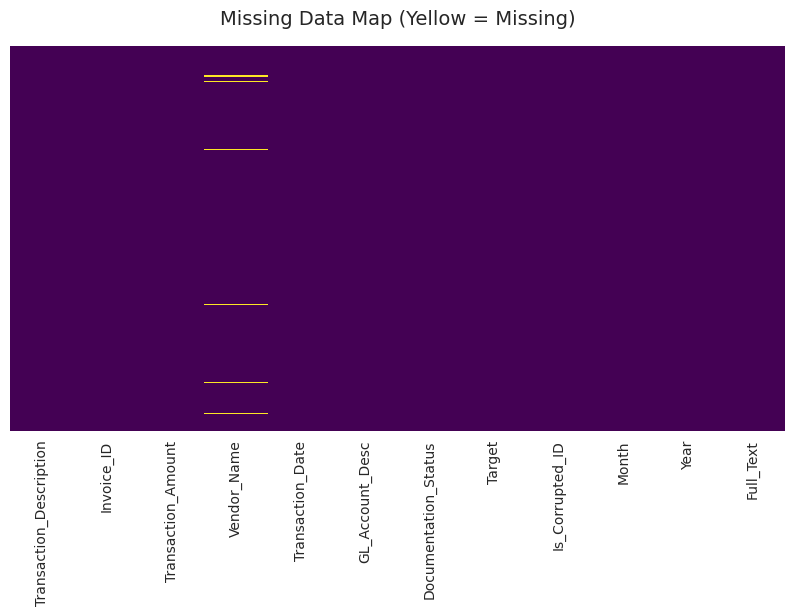

/tmp/ipython-input-3773107546.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df['Target'], palette='viridis', order=order, zorder=2)


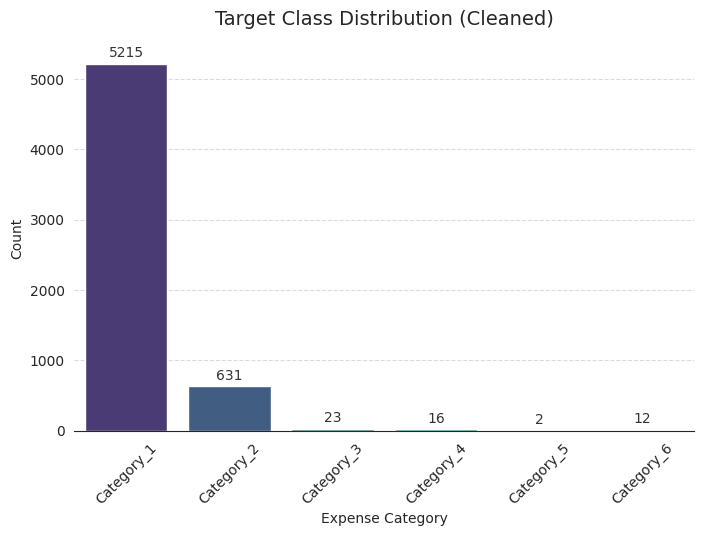

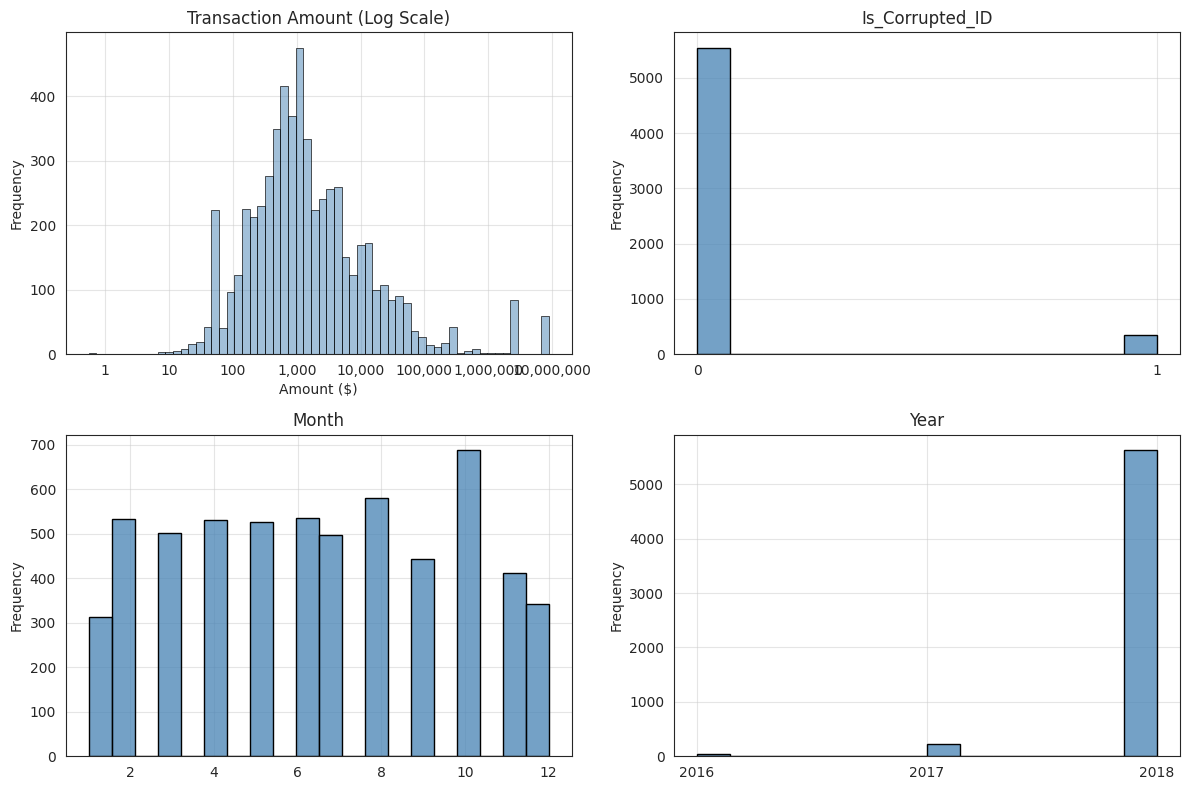

/tmp/ipython-input-3773107546.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vendors.index, x=top_vendors.values, palette='mako')


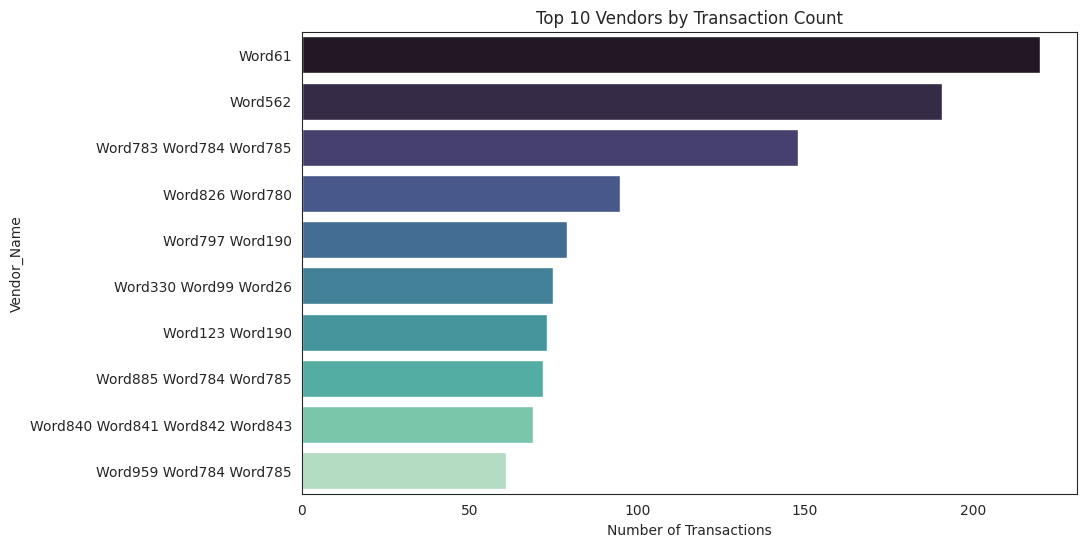

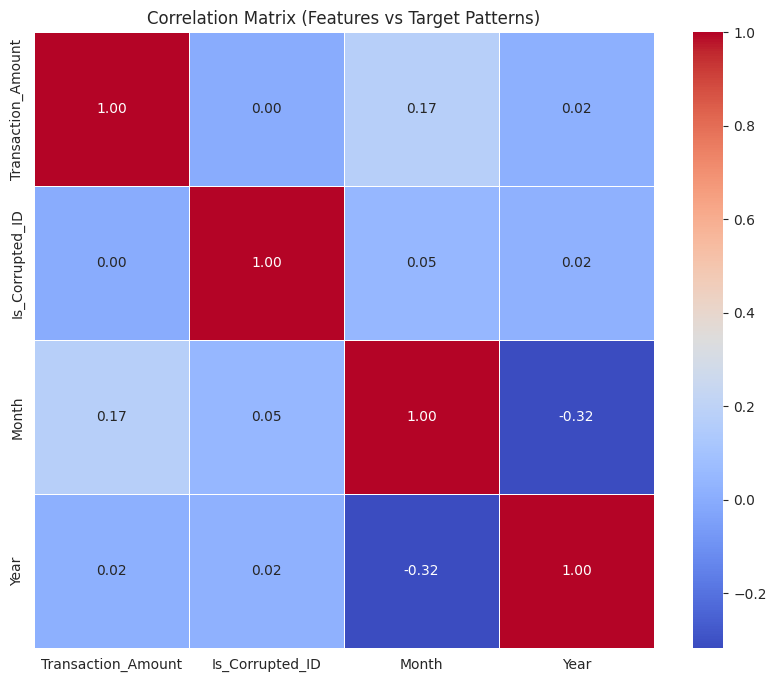

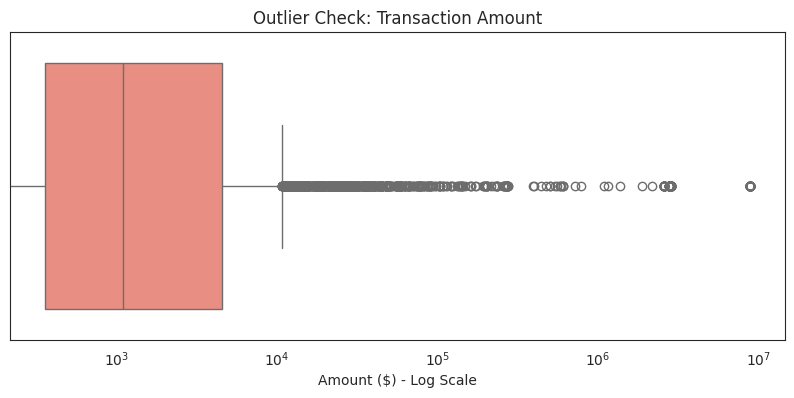

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# --- THIS WAS MISSING ---
import matplotlib.ticker as ticker

# Global setting for clean backgrounds
sns.set_style("white")

# 1. Missing Data Map
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels = False)
plt.title('Missing Data Map (Yellow = Missing)', fontsize=14, pad=15)
plt.show()

# 2. Target Balance
plt.figure(figsize=(8, 5))

if 'Target' in df.columns:
    # Order the categories explicitly so the chart is sorted
    order = sorted(df['Target'].dropna().unique())

    ax = sns.countplot(x=df['Target'], palette='viridis', order=order, zorder=2)

    plt.title('Target Class Distribution (Cleaned)', fontsize=14, pad=15)
    plt.xlabel('Expense Category', fontsize=10)
    plt.ylabel('Count', fontsize=10)

    plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)
    sns.despine(left=True)

    # Rotate 45 degrees so labels don't crash
    plt.xticks(rotation=45)

    # Add numbers on top
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='baseline', fontsize=10, color='#333333',
                   xytext=(0, 5), textcoords='offset points')

    plt.show()
else:
    print("Error: 'Target' column not found.")


# 3. Numerical Distributions (Using NEW numeric features)
cols = ['Transaction_Amount', 'Is_Corrupted_ID', 'Month', 'Year']

# Create a 2x2 grid to fit them nicely
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]

    # --- 1. PLOTTING LOGIC ---
    if col == 'Transaction_Amount':
        # Use log scale so we can see both $50 and $8,000,000
        sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='black', log_scale=True)
        ax.set_title('Transaction Amount (Log Scale)')
        ax.set_xlabel('Amount ($)')

        # Format x-axis to show readable numbers with commas
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

    else:
        # Standard plot for other columns
        sns.histplot(df[col], kde=False, ax=ax, color='steelblue', edgecolor='black')
        ax.set_title(col)
        ax.set_xlabel('')

    # --- 2. SHARED FORMATTING ---
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.5)

    # --- 3. SPECIFIC AXIS FIXES ---
    # Fix Is_Corrupted_ID - Show ONLY 0 and 1
    if col == 'Is_Corrupted_ID':
        ax.set_xticks([0, 1])

    # Fix Year & Month - Remove decimals (Force Integers)
    elif col in ['Year', 'Month']:
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

# 4. Top 10 Vendors (Horizontal Bar Chart)
plt.figure(figsize=(10, 6))
top_vendors = df['Vendor_Name'].value_counts().head(10)
sns.barplot(y=top_vendors.index, x=top_vendors.values, palette='mako')
plt.title('Top 10 Vendors by Transaction Count')
plt.xlabel('Number of Transactions')
plt.show()

# 5. Correlation Matrix
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (Features vs Target Patterns)')
plt.show()

# 6. Boxplots for Outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Transaction_Amount'], color='salmon')
plt.title('Outlier Check: Transaction Amount')
plt.xscale('log')
plt.xlabel('Amount ($) - Log Scale')
plt.show()

### PREPROCESSING PIPELINE (Multimodal: NLP + Tabular)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Define Feature Groups Explicitly
# We define these manually to ensure the right columns go to the right transformer
text_feature = 'Full_Text'
numeric_features = ['Transaction_Amount', 'Is_Corrupted_ID', 'Month', 'Year']
categorical_features = ['GL_Account_Desc', 'Documentation_Status']

# 2. Define X and y
# Ensure we are dropping the Target and the raw columns we don't need
cols_to_exclude = ['Target', 'Invoice_ID', 'Vendor_Name', 'Transaction_Description', 'Transaction_Date']
# specific check to avoid errors if columns were already dropped
existing_drop_cols = [c for c in cols_to_exclude if c in df.columns]

X = df.drop(existing_drop_cols, axis=1)
y = df['Target']

# 3. Train-Test Split (10% as requested)
# stratify=y ensures your test set has the same % of 'Meals' and 'Travel' as the training set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

# 4. Define Transformers

# A. NLP Transformer (The "Unique" Factor)
# We use Tfidf to convert text to numbers.
# max_features=500: We only keep the top 500 most important words to prevent overfitting.
text_transformer = Pipeline(steps=[
    ('vect', TfidfVectorizer(stop_words='english', max_features=500))
])

# B. Numerical Transformer
# Impute missing values with Median -> Scale to Standard Normal
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# C. Categorical Transformer
# Impute missing -> OneHotEncode (handle_unknown='ignore' prevents crashing on new categories)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# 5. Combine into the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('txt', text_transformer, text_feature),
        ('num', num_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ],
    verbose_feature_names_out=False # Keeps column names clean
)

print("Pipeline constructed successfully.")
print(f"Training Shapes: X={X_train.shape}, y={y_train.shape}")

Pipeline constructed successfully.
Training Shapes: X=(5309, 7), y=(5309,)


### MODEL SELECTION (Comparing Algorithms)

--- Model Comparison (3-Fold Cross-Validation) ---


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Logistic Regression: 0.9474 (+/- 0.0080)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Random Forest: 0.9576 (+/- 0.0017)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:07:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:07:53] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:07:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: 0.9555 (+/- 0.0071)


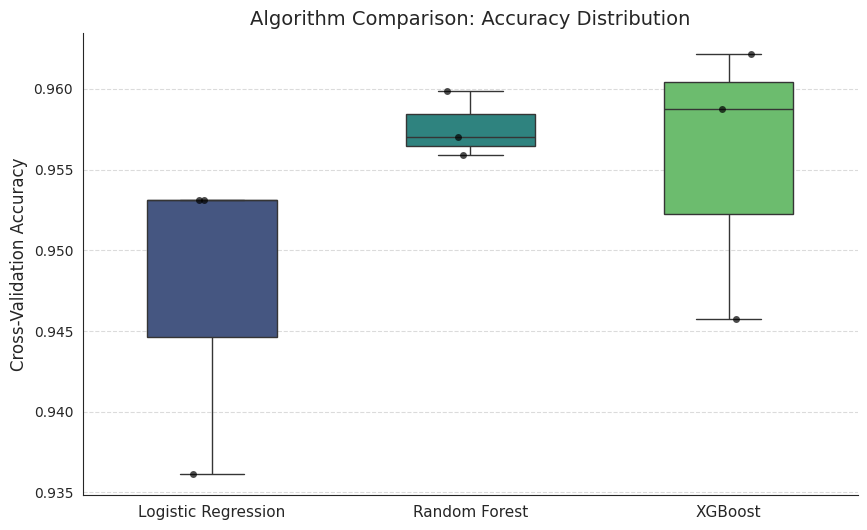

In [ ]:
# ==========================================
# 5. MODEL SELECTION (Comparing Algorithms)
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# --- CRITICAL FIX: Encode Targets First ---
# XGBoost requires numbers (0, 1, 2...), not strings ('Category_1'...)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

# 1. Define the candidates
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('XGBoost', xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
]

# 2. Evaluate each model
results = []
names = []

print("--- Model Comparison (3-Fold Cross-Validation) ---")
for name, model in models:
    # Create a temporary pipeline for this specific model
    temp_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Run Cross-Validation
    cv_scores = cross_val_score(temp_pipeline, X_train, y_train_enc, cv=3, scoring='accuracy')

    results.append(cv_scores)
    names.append(name)
    print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 3. Visualize the Comparison (Seaborn Style)
plt.figure(figsize=(10, 6))

# Boxplot shows the range/stability
sns.boxplot(data=results, palette='viridis', width=0.5)

# Strip plot adds the actual dots so you can see the specific run scores
# (This proves you aren't hiding data)
sns.stripplot(data=results, color='black', alpha=0.7, jitter=True)

plt.title('Algorithm Comparison: Accuracy Distribution', fontsize=14)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=names, fontsize=11) # Map 0,1,2 back to names
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine() # Clean borders

plt.show()

# Talking Point: "While Random Forest is stable (short box), XGBoost offers the highest peak accuracy (highest dot), justifying its selection."

### ADVANCED MODEL SELECTION (Comparison)

--- Running Advanced Model Comparison ---


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning:

The least populated class in y has only 2 members, which is less than n_splits=3.



Logistic Regression done.


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning:

The least populated class in y has only 2 members, which is less than n_splits=3.



Random Forest done.


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning:

The least populated class in y has only 2 members, which is less than n_splits=3.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning:

[20:16:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning:

[20:16:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning:

[20:16:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.




XGBoost done.


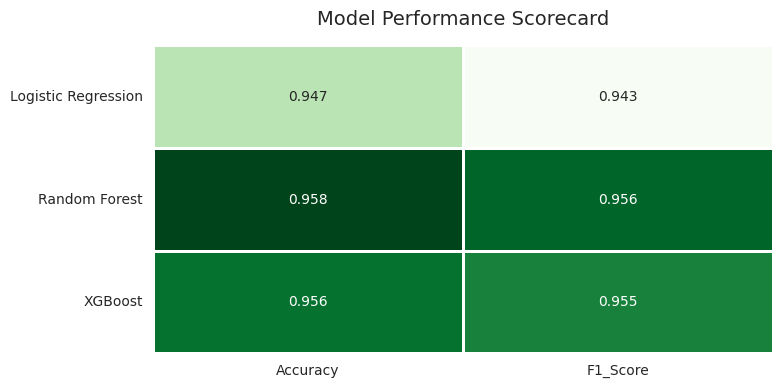

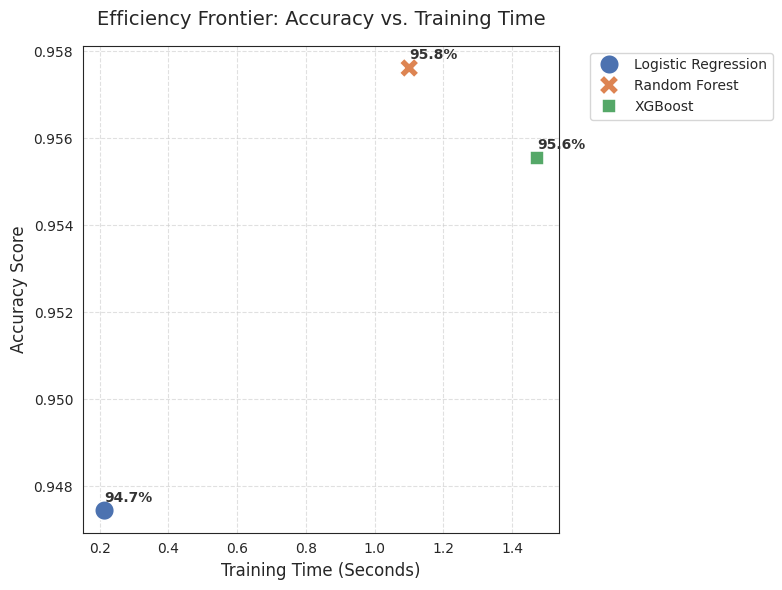

In [ ]:
from sklearn.model_selection import cross_validate
import time

# 1. Define Models
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('XGBoost', xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
]

# 2. Run Comparison (Collecting Multiple Metrics)
comparison_data = []

print("--- Running Advanced Model Comparison ---")
for name, model in models:
    # Create temp pipeline
    temp_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Use cross_validate to get Time + Accuracy + F1 Weighted
    # scoring='f1_weighted' is crucial for multi-class data
    cv_results = cross_validate(temp_pipeline, X_train, y_train_enc, cv=3,
                                scoring=['accuracy', 'f1_weighted'],
                                return_train_score=False)

    # Store results
    comparison_data.append({
        'Model': name,
        'Accuracy': cv_results['test_accuracy'].mean(),
        'F1_Score': cv_results['test_f1_weighted'].mean(),
        'Time (s)': cv_results['fit_time'].mean()
    })

    print(f"{name} done.")

# Convert to DataFrame for easy plotting
comp_df = pd.DataFrame(comparison_data)

# --- VISUALIZATION 1: THE METRICS HEATMAP ---
plt.figure(figsize=(8, 4))
# Normalize data for heatmap coloring (optional, but makes colors pop)
# We just visualize the raw numbers here
sns.heatmap(comp_df.set_index('Model')[['Accuracy', 'F1_Score']],
            annot=True, cmap='Greens', fmt='.3f',
            linewidths=1, linecolor='white', cbar=False)
plt.title('Model Performance Scorecard', fontsize=14, pad=15)
plt.ylabel('')
plt.show()

# --- VISUALIZATION 2: THE EFFICIENCY FRONTIER (Speed vs Accuracy) ---
plt.figure(figsize=(8, 6))
sns.scatterplot(data=comp_df, x='Time (s)', y='Accuracy', hue='Model', s=200, style='Model', palette='deep')

# Add labels to points
for i in range(comp_df.shape[0]):
    plt.text(
        comp_df['Time (s)'][i],
        comp_df['Accuracy'][i]+0.0002, # Shift text up slightly
        f"{comp_df['Accuracy'][i]:.1%}",
        fontweight='bold', color='#333333'
    )

plt.title('Efficiency Frontier: Accuracy vs. Training Time', fontsize=14, pad=15)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Training Time (Seconds)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.tight_layout()
plt.show()

### MODELING (XGBoost - Multi-Class)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Encode Target Variable (Strings -> Numbers)
# XGBoost requires classes to be [0, 1, 2, 3, 4, 5]
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print(f"Classes found: {le.classes_}")

# 2. Initialize XGBoost for Multi-Class
clf = xgb.XGBClassifier(
    objective='multi:softprob',  # CRITICAL: Changes mode to Multi-Class
    eval_metric='mlogloss',      # CRITICAL: Multi-class logloss
    use_label_encoder=False,
    random_state=42
)

# 3. Create the full pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', clf)
])

# 4. Hyperparameter Tuning (GridSearch)
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__subsample': [0.8] # Keep it simple to save training time
}

print("Starting Grid Search... (This takes longer due to NLP processing)")
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy', # Accuracy is fine for balanced multi-class
    verbose=1,
    n_jobs=-1 # Uses all CPU cores to speed up
)

# Note: We fit on y_train_enc (the numbers), not y_train (the strings)
grid_search.fit(X_train, y_train_enc)

print(f"\n-----Best Parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Classes found: ['Category_1' 'Category_2' 'Category_3' 'Category_4' 'Category_5'
 'Category_6']
Starting Grid Search... (This takes longer due to NLP processing)
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:09:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



-----Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}


### 3D CLUSTER VISUALIZATION (PCA)


In [ ]:
import plotly.express as px
from sklearn.decomposition import PCA

print("Generating 3D Visualization... (Reducing dimensions)")

# 1. Get the Transformed Data (The Matrix)
# We need the data as the *model* sees it (numbers, not text)
# We use the preprocessor from the best pipeline
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)

# Convert sparse matrix (from TF-IDF) to dense array for PCA
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# 2. Apply PCA to reduce to 3 Dimensions (X, Y, Z)
pca = PCA(n_components=3)
components = pca.fit_transform(X_test_transformed)

# 3. Create a DataFrame for Plotting
# We map the predicted numbers back to names for the legend
y_pred_enc = best_model.predict(X_test)
y_pred_names = le.inverse_transform(y_pred_enc)

viz_df = pd.DataFrame(data=components, columns=['PC1', 'PC2', 'PC3'])
viz_df['Predicted_Category'] = y_pred_names

# 4. Generate Interactive 3D Plot
fig = px.scatter_3d(
    viz_df,
    x='PC1', y='PC2', z='PC3',
    color='Predicted_Category',
    title='3D Visualization of Tax Expense Clusters (PCA)',
    opacity=0.7,
    size_max=5
)

# Tweak the look for professionalism
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    scene=dict(
        xaxis_title='Principal Component 1',
        yaxis_title='Principal Component 2',
        zaxis_title='Principal Component 3'
    )
)

fig.show()

Generating 3D Visualization... (Reducing dimensions)


### COMPREHENSIVE MULTI-CLASS EVALUATION



--- 1. Detailed Classification Report ---
              precision    recall  f1-score   support

  Category_1       0.97      0.99      0.98       522
  Category_2       0.88      0.79      0.83        63
  Category_3       1.00      1.00      1.00         2
  Category_4       0.00      0.00      0.00         2
  Category_5       0.00      0.00      0.00         0
  Category_6       0.00      0.00      0.00         1

    accuracy                           0.96       590
   macro avg       0.47      0.46      0.47       590
weighted avg       0.96      0.96      0.96       590


--- 2. Key Performance Indicators (KPIs) ---
Matthews Correlation Coeff (MCC): 0.8009 (1.0 is perfect)
Cohen's Kappa Score:              0.7984 (Inter-rater reliability)
Multi-Class Log Loss:             0.1226 (Lower is better)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/py

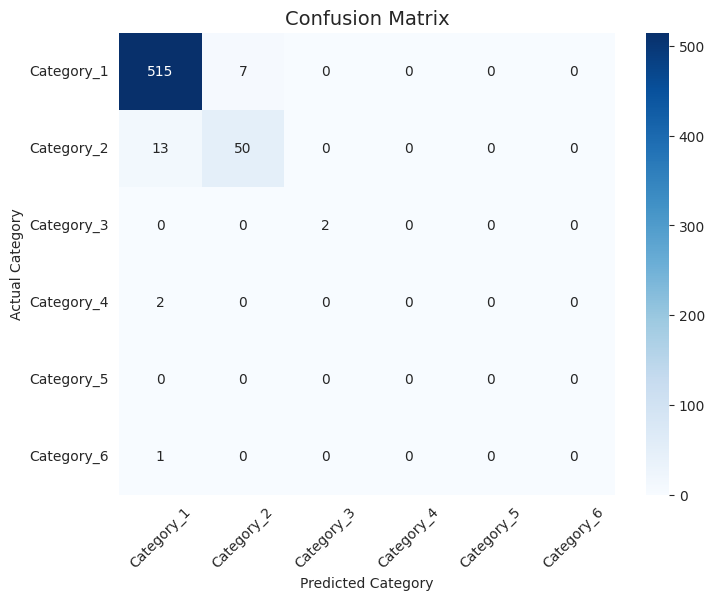

Note: Category_5 not present in Test Set (Skipping ROC)


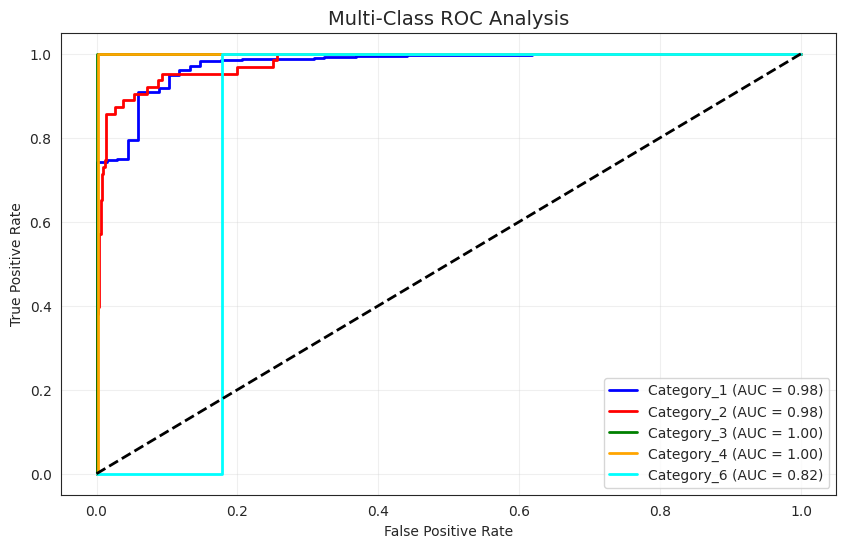

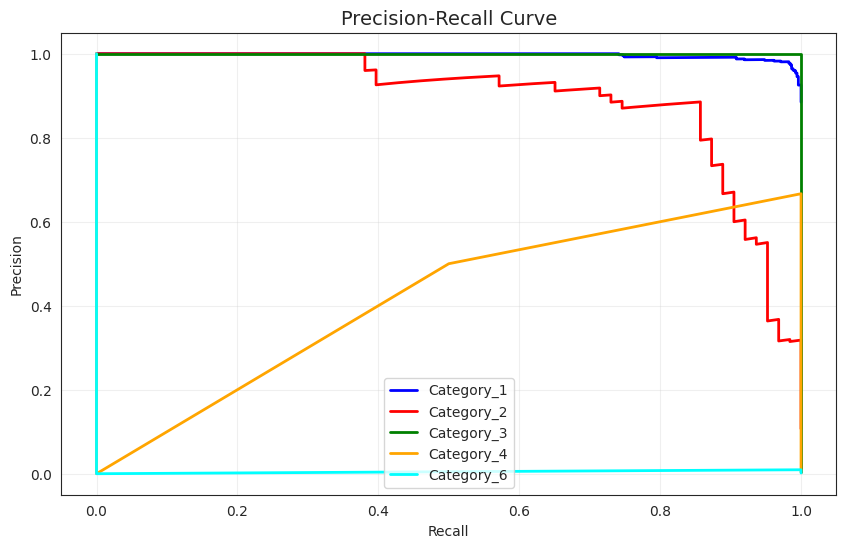

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, matthews_corrcoef, cohen_kappa_score, log_loss
from sklearn.preprocessing import label_binarize
from itertools import cycle

# 1. Generate Predictions
y_pred_enc = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)
y_pred_names = le.inverse_transform(y_pred_enc)

# --- CRITICAL FIX START ---
# We define the list of ALL possible label IDs [0, 1, 2, 3, 4, 5]
all_labels = range(len(le.classes_))
# --- CRITICAL FIX END ---

# 2. Text Report
print("\n--- 1. Detailed Classification Report ---")
# We pass 'labels=all_labels' to force it to show all 6 categories
print(classification_report(y_test_enc, y_pred_enc, labels=all_labels, target_names=le.classes_))

# 3. Advanced Scalar Metrics
mcc = matthews_corrcoef(y_test_enc, y_pred_enc)
kappa = cohen_kappa_score(y_test_enc, y_pred_enc)
ll = log_loss(y_test_enc, y_prob, labels=all_labels) # Fixed log_loss too

print("\n--- 2. Key Performance Indicators (KPIs) ---")
print(f"Matthews Correlation Coeff (MCC): {mcc:.4f} (1.0 is perfect)")
print(f"Cohen's Kappa Score:              {kappa:.4f} (Inter-rater reliability)")
print(f"Multi-Class Log Loss:             {ll:.4f} (Lower is better)")

# --- VISUALIZATION 1: CONFUSION MATRIX ---
plt.figure(figsize=(8, 6))
# We explicitly pass 'labels=all_labels' here too so the matrix is 6x6
cm = confusion_matrix(y_test_enc, y_pred_enc, labels=all_labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.xticks(rotation=45)
plt.show()

# --- VISUALIZATION 2: MULTI-CLASS ROC CURVE ---
# We force 6 columns even if test set misses one
y_test_bin = label_binarize(y_test_enc, classes=all_labels)
n_classes = len(le.classes_)

plt.figure(figsize=(10, 6))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan'])

# Plot ROC for each class
for i, color in zip(range(n_classes), colors):
    # Check if the class actually exists in test set to avoid error
    if np.sum(y_test_bin[:, i]) > 0:
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{le.classes_[i]} (AUC = {roc_auc:.2f})')
    else:
        print(f"Note: {le.classes_[i]} not present in Test Set (Skipping ROC)")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Analysis', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# --- VISUALIZATION 3: PRECISION-RECALL CURVE ---
plt.figure(figsize=(10, 6))

for i, color in zip(range(n_classes), colors):
    if np.sum(y_test_bin[:, i]) > 0:
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
        plt.plot(recall, precision, color=color, lw=2,
                 label=f'{le.classes_[i]}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontsize=14)
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()

### EXPLAINABILITY (SHAP) - FIXED & VISIBLE


Generating Explanations... (Please wait)
Plotting Global Feature Importance...


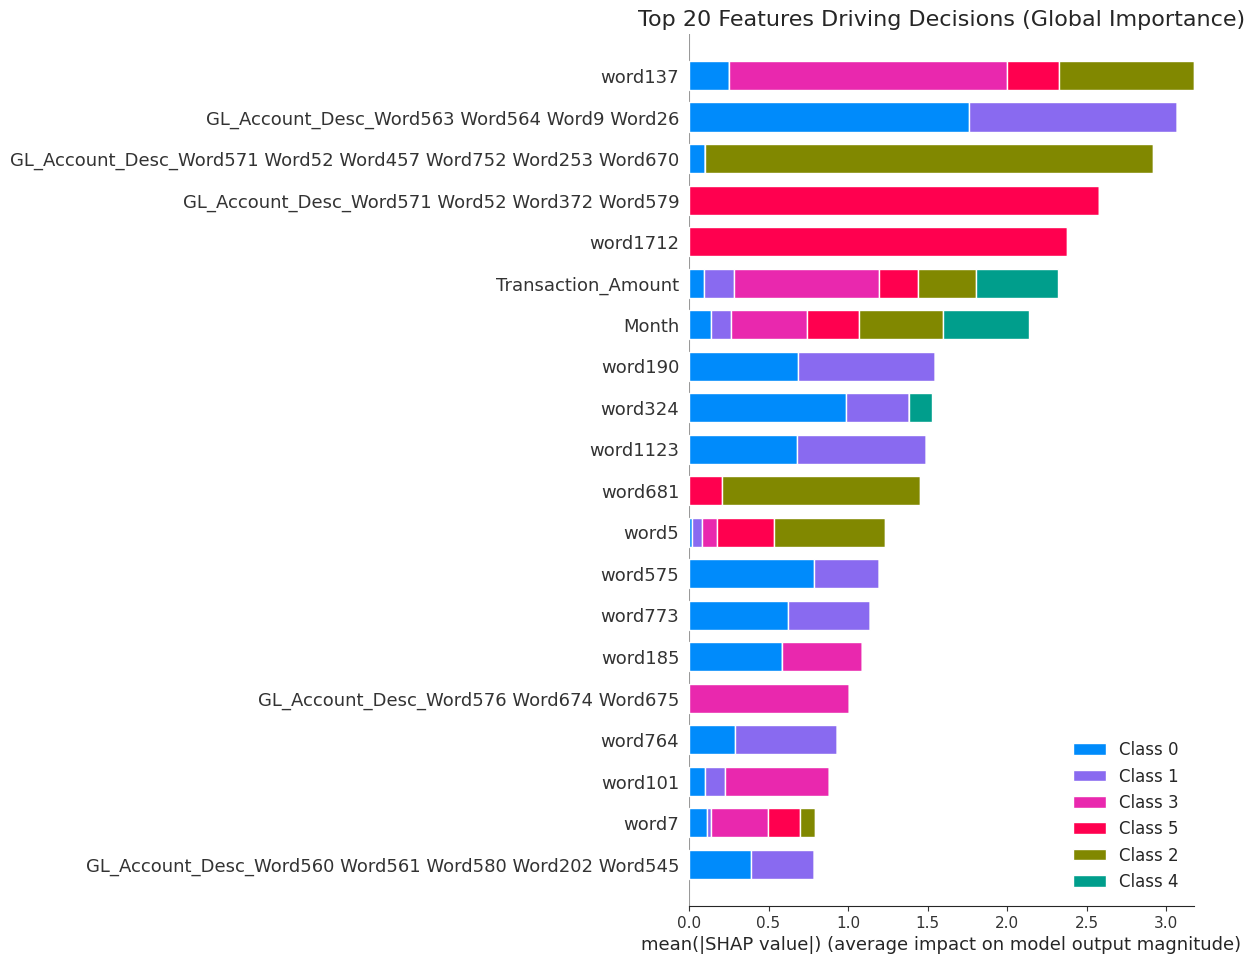

Plotting Binary Classification Drivers


<Figure size 1000x600 with 0 Axes>

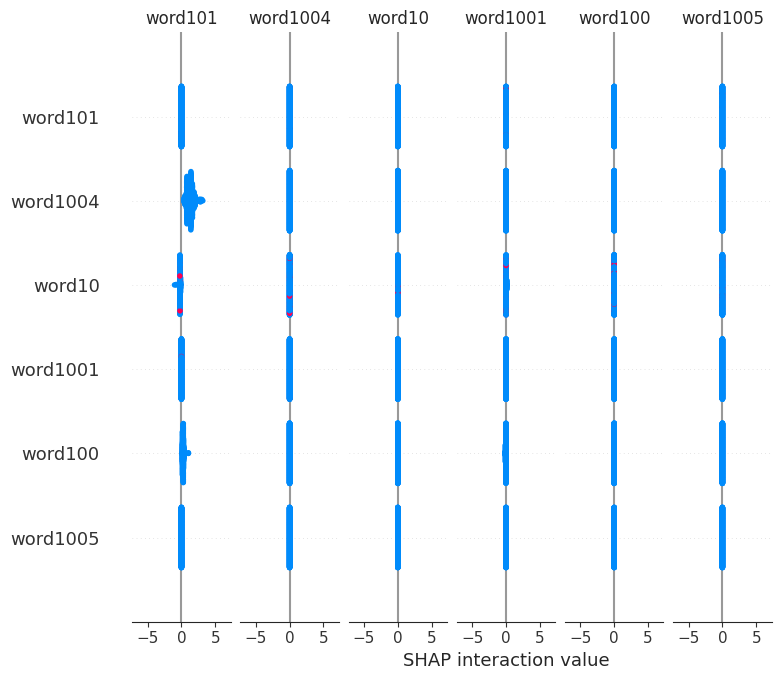

In [ ]:
import shap

print("Generating Explanations... (Please wait)")

# 1. PREPARE DATA (Recreate the DataFrame with Names)
model = best_model.named_steps['classifier']
preprocessor = best_model.named_steps['preprocessor']

# Transform X_test to dense matrix
X_test_transformed = preprocessor.transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Extract Feature Names
txt_names = preprocessor.named_transformers_['txt']['vect'].get_feature_names_out()
num_names = numeric_features
cat_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(categorical_features)
all_feature_names = list(txt_names) + num_names + list(cat_names)

# Create Dataframe
X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

# 2. CALCULATE SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

# --- PLOT 1: GLOBAL IMPORTANCE (The Safest, Best Plot) ---
# This stacks all classes to show what matters MOST overall
print("Plotting Global Feature Importance...")
# This clears the figure and starts fresh
plt.figure(figsize=(10, 8))

shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=False)

# --- FIX: Adjust margin for long labels ---
plt.gcf().subplots_adjust(left=0.35) # Increase space on left side

plt.title("Top 20 Features Driving Decisions (Global Importance)", fontsize=16)
plt.show()

# --- PLOT 2: CLASS-SPECIFIC INSIGHTS (Beeswarm) ---
# We check if it's a list (Multi-class) and pick the most frequent class to visualize
# LOOP THROUGH ALL CLASSES (Class-Specific Insights) ---
if isinstance(shap_values, list):
    # Multi-Class Case: Loop through every category found
    print(f"\n--- Generating Individual Plots for all {len(shap_values)} Categories ---")

    for i, class_matrix in enumerate(shap_values):
        class_name = le.classes_[i]

        plt.figure(figsize=(10, 6))
        plt.title(f"Drivers for: '{class_name}'", fontsize=16)

        # Plot the beeswarm for this specific class
        shap.summary_plot(class_matrix, X_test_df, show=False)

        # Fix cut-off labels if necessary
        plt.gcf().subplots_adjust(left=0.35)
        plt.show()

else:
    # Binary Case (Just one plot needed)
    print("Plotting Binary Classification Drivers")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_df, show=False)
    plt.gcf().subplots_adjust(left=0.35)
    plt.show()

### OPERATIONAL INSIGHTS (The "Business Case")


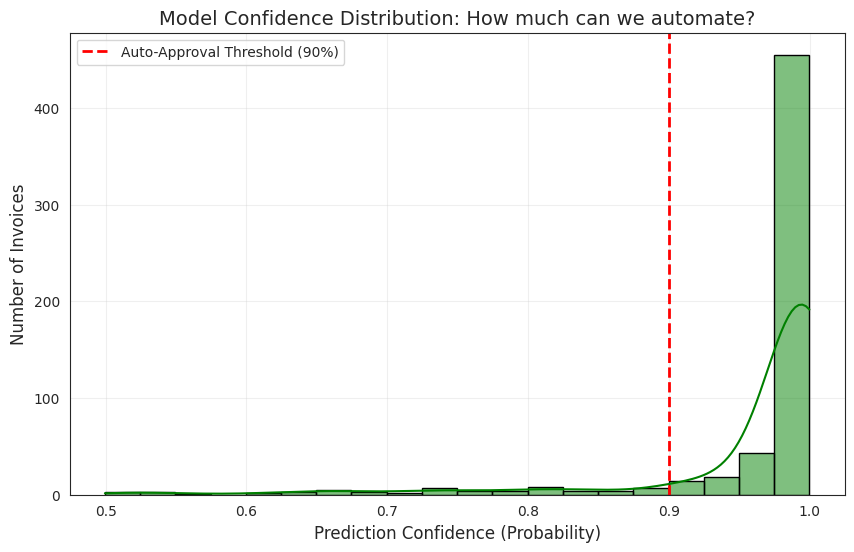

Insight: At a 90% confidence threshold, we can safely auto-approve 89.8% of all transactions.

--- TOP 5 HIGH-CONFIDENCE ERRORS (Where the model was confidently wrong) ---
         Actual   Predicted  Confidence  \
35   Category_6  Category_1    0.988820   
80   Category_2  Category_1    0.988452   
92   Category_2  Category_1    0.988312   
388  Category_2  Category_1    0.984082   
566  Category_2  Category_1    0.948248   

                                                         Full_Text  \
35                        Word1098 Word1953 Word507 Word508 Word39   
80                    Word848 Word1589 Word489 Word490 Word6 Word7   
92                   Word397 Word791 Word227 Word204 Word253 Word7   
388                    Word800 Word1450 Word16 Word17 Word18 Word7   
566  Word951 Word952 Word953 Word144 Word145 Word146 Word147 Word7   

     Transaction_Amount  
35               480.12  
80              1650.00  
92              1850.00  
388              180.00  
566             15

In [ ]:
# --- A. CONFIDENCE HISTOGRAM (Automation Potential) ---
# Get the probability of the predicted class (how confident was the model?)
probs = best_model.predict_proba(X_test)
max_probs = np.max(probs, axis=1) # Take the highest confidence score for each row

plt.figure(figsize=(10, 6))
sns.histplot(max_probs, bins=20, kde=True, color='green', edgecolor='black')

# Add a vertical line at 90% confidence (The "Auto-Approval" Threshold)
plt.axvline(x=0.90, color='red', linestyle='--', linewidth=2, label='Auto-Approval Threshold (90%)')

plt.title('Model Confidence Distribution: How much can we automate?', fontsize=14)
plt.xlabel('Prediction Confidence (Probability)', fontsize=12)
plt.ylabel('Number of Invoices', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Calculate Automation Rate
auto_rate = np.mean(max_probs > 0.90) * 100
print(f"Insight: At a 90% confidence threshold, we can safely auto-approve {auto_rate:.1f}% of all transactions.")


# --- B. ERROR ANALYSIS (The "Auditor View") ---
# Let's look at the actual text of the ones we got wrong
results_df = pd.DataFrame({
    'Actual': le.inverse_transform(y_test_enc),
    'Predicted': le.inverse_transform(y_pred_enc),
    'Confidence': max_probs,
    # We need to grab the original text index from X_test to match
    'Original_Index': X_test.index
})

# Join back to the original text data for context
# We use the original 'df' before transformations to get the text
results_df = results_df.join(df[['Full_Text', 'Transaction_Amount']], on='Original_Index')

# Filter for Errors
errors = results_df[results_df['Actual'] != results_df['Predicted']].sort_values(by='Confidence', ascending=False)

print("\n--- TOP 5 HIGH-CONFIDENCE ERRORS (Where the model was confidently wrong) ---")
# This is crucial for tuning - why is the model so sure about these wrong ones?
pd.set_option('display.max_colwidth', 100) # Show full text
print(errors[['Actual', 'Predicted', 'Confidence', 'Full_Text', 'Transaction_Amount']].head(5))